# Enterprise Phase 1: Data Understanding & EDA

This notebook is organized as a professional analytics workflow with clear sections, reusable code, and business interpretations.


## 1. Imports



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize']=(10,5)
plt.rcParams['axes.grid']=True

DATA_PATH='../data/datasets/american_bankruptcy.csv'
df=pd.read_csv(DATA_PATH)


## 2. Utility Functions



In [2]:
def dataset_summary(df):
    return pd.DataFrame({
        'Metric':['Rows','Columns','Missing Values','Duplicate Rows','Companies','Years'],
        'Value':[len(df),df.shape[1],int(df.isna().sum().sum()),
                 int(df.duplicated().sum()),
                 df['company_name'].nunique(),
                 f"{df['year'].min()}-{df['year'].max()}"]
    })

def missing_report(df):
    r=df.isna().sum().to_frame('Missing')
    r['Percent']=100*r['Missing']/len(df)
    return r.sort_values('Percent',ascending=False)


## Dataset Preview



In [3]:
display(df.head()); display(df.tail())

,company_name,status_label,year,X1,X2,X3,X4,X5,X6,X7,...,X9,X10,X11,X12,X13,X14,X15,X16,X17,X18
0,C_1,alive,1999,511.267,833.107,18.373,89.031,336.018,35.163,128.348,...,1024.333,740.998,180.447,70.658,191.226,163.816,201.026,1024.333,401.483,935.302
1,C_1,alive,2000,485.856,713.811,18.577,64.367,320.590,18.531,115.187,...,874.255,701.854,179.987,45.790,160.444,125.392,204.065,874.255,361.642,809.888
2,C_1,alive,2001,436.656,526.477,22.496,27.207,286.588,-58.939,77.528,...,638.721,710.199,217.699,4.711,112.244,150.464,139.603,638.721,399.964,611.514
3,C_1,alive,2002,396.412,496.747,27.172,30.745,259.954,-12.410,66.322,...,606.337,686.621,164.658,3.573,109.590,203.575,124.106,606.337,391.633,575.592
4,C_1,alive,2003,432.204,523.302,26.680,47.491,247.245,3.504,104.661,...,651.958,709.292,248.666,20.811,128.656,131.261,131.884,651.958,407.608,604.467


,company_name,status_label,year,X1,X2,X3,X4,X5,X6,X7,...,X9,X10,X11,X12,X13,X14,X15,X16,X17,X18
78677,C_8971,alive,2014,233.211,43.338,14.094,45.615,3.376,25.261,22.846,...,104.223,1099.101,184.666,31.521,60.885,28.197,28.095,104.223,225.887,58.608
78678,C_8971,alive,2015,105.559,59.184,42.592,202.133,2.288,129.688,54.611,...,291.153,1865.926,770.103,159.541,231.969,88.128,157.783,291.153,880.327,89.020
78679,C_8971,alive,2016,63.971,69.074,65.057,79.051,2.581,-1.442,42.467,...,169.858,1746.235,683.985,13.994,100.784,85.765,156.341,169.858,770.233,90.807
78680,C_8971,alive,2017,135.207,66.527,65.330,69.171,2.013,-20.401,27.217,...,161.884,1736.110,694.035,3.841,95.357,82.010,135.941,161.884,776.697,92.713
78681,C_8971,alive,2018,82.589,68.817,65.201,67.262,2.112,-50.946,45.839,...,160.513,1625.370,632.122,2.061,91.696,79.365,84.995,160.513,712.687,93.251


## Dataset Summary



In [4]:
display(dataset_summary(df))

,Metric,Value
0,Rows,78682
1,Columns,21
2,Missing Values,0
3,Duplicate Rows,0
4,Companies,8971
5,Years,1999-2018


## Schema



In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 78682 entries, 0 to 78681
Data columns (total 21 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   company_name  78682 non-null  str    
 1   status_label  78682 non-null  str    
 2   year          78682 non-null  int64  
 3   X1            78682 non-null  float64
 4   X2            78682 non-null  float64
 5   X3            78682 non-null  float64
 6   X4            78682 non-null  float64
 7   X5            78682 non-null  float64
 8   X6            78682 non-null  float64
 9   X7            78682 non-null  float64
 10  X8            78682 non-null  float64
 11  X9            78682 non-null  float64
 12  X10           78682 non-null  float64
 13  X11           78682 non-null  float64
 14  X12           78682 non-null  float64
 15  X13           78682 non-null  float64
 16  X14           78682 non-null  float64
 17  X15           78682 non-null  float64
 18  X16           78682 non-null  float64

## Summary Statistics



In [6]:
display(df.describe(include='all').T)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
company_name,78682,8971,C_7,20,NaN,NaN,NaN,NaN,NaN,NaN,NaN
status_label,78682,2,alive,73462,NaN,NaN,NaN,NaN,NaN,NaN,NaN
year,78682.0,NaN,NaN,NaN,2007.506317,5.742768,1999.0,2002.0,2007.0,2012.0,2018.0
X1,78682.0,NaN,NaN,NaN,880.362485,3928.564794,-7.76,18.924,100.4495,431.52675,169662.0
X2,78682.0,NaN,NaN,NaN,1594.529029,8930.484664,-366.645,17.03825,103.661,634.548,374623.0
X3,78682.0,NaN,NaN,NaN,121.234256,652.376804,0.0,1.192,7.9295,47.97175,28430.0
X4,78682.0,NaN,NaN,NaN,376.759424,2012.023142,-21913.0,-0.811,15.0345,139.65525,81730.0
X5,78682.0,NaN,NaN,NaN,201.605717,1060.766096,0.0,0.0,7.023,74.74725,62567.0
X6,78682.0,NaN,NaN,NaN,129.382453,1265.532022,-98696.0,-7.41575,1.616,40.14425,104821.0
X7,78682.0,NaN,NaN,NaN,286.832743,1335.978571,-0.006,3.28125,22.82,131.5805,65812.0


## Missing Value Analysis



In [7]:
display(missing_report(df))

,Missing,Percent
company_name,0,0.0
status_label,0,0.0
year,0,0.0
X1,0,0.0
X2,0,0.0
X3,0,0.0
X4,0,0.0
X5,0,0.0
X6,0,0.0
X7,0,0.0


## Duplicate Analysis



In [8]:
print(df.duplicated().sum());print(df.duplicated(subset=['company_name','year']).sum())

0


0


## Target Distribution



status_label
alive     73462
failed     5220
Name: count, dtype: int64

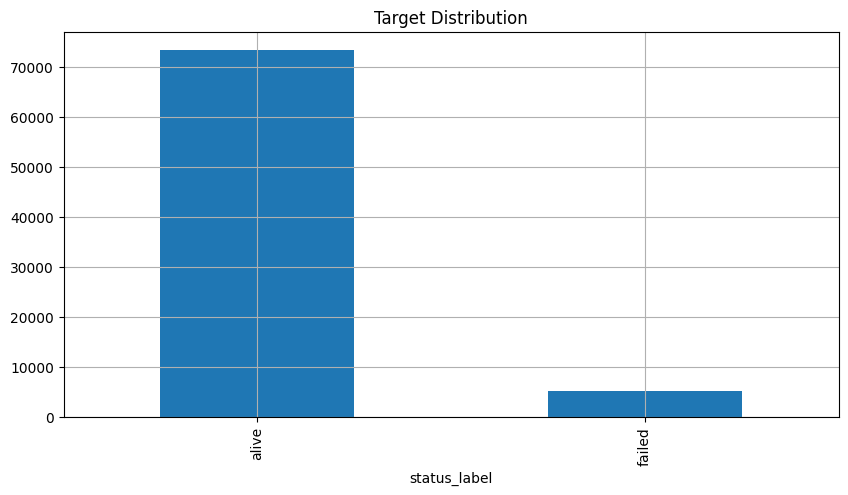

In [9]:
vc=df['status_label'].value_counts();display(vc);vc.plot(kind='bar',title='Target Distribution');plt.show()

## Year Distribution



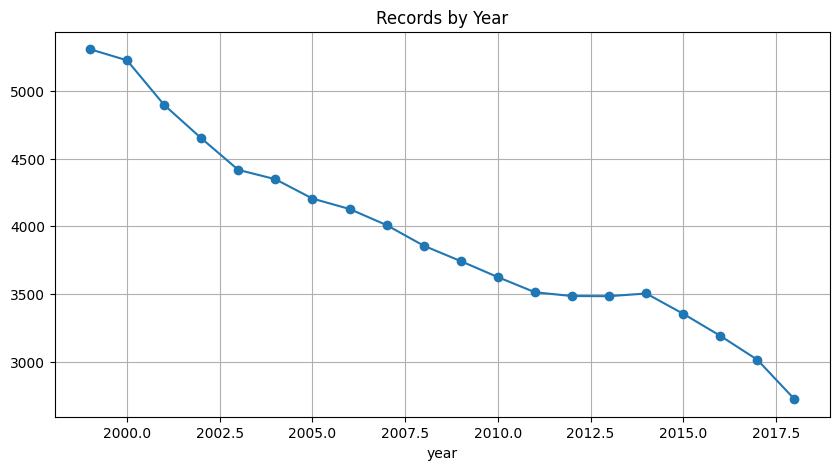

In [10]:
yr=df['year'].value_counts().sort_index();yr.plot(marker='o');plt.title('Records by Year');plt.show()

## Company Analysis



count    8971.000000
mean        8.770706
std         6.421565
min         1.000000
25%         3.000000
50%         7.000000
75%        14.000000
max        20.000000
dtype: float64

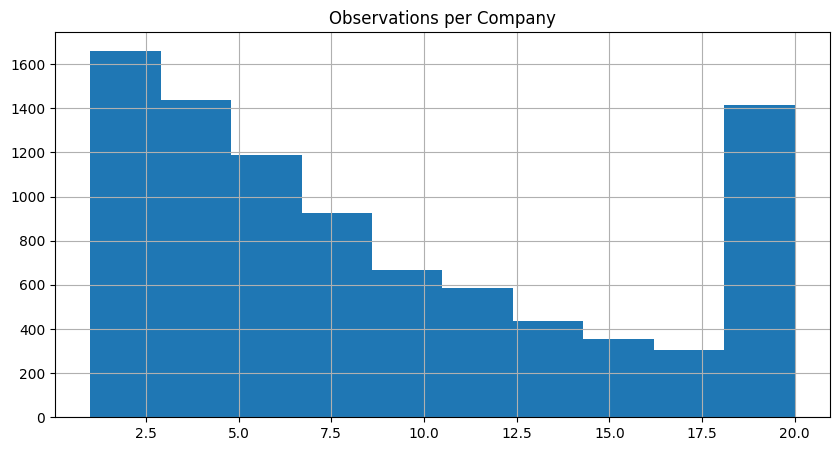

In [11]:
obs=df.groupby('company_name').size();display(obs.describe());obs.hist();plt.title('Observations per Company');plt.show()

## Numeric Feature Profiling



In [12]:
num=df.select_dtypes(include='number');display(num.describe().T);

,count,mean,std,min,25%,50%,75%,max
year,78682.0,2007.506317,5.742768,1999.0000,2002.00000,2007.00000,2012.00000,2018.00
X1,78682.0,880.362485,3928.564794,-7.7600,18.92400,100.44950,431.52675,169662.00
X2,78682.0,1594.529029,8930.484664,-366.6450,17.03825,103.66100,634.54800,374623.00
X3,78682.0,121.234256,652.376804,0.0000,1.19200,7.92950,47.97175,28430.00
X4,78682.0,376.759424,2012.023142,-21913.0000,-0.81100,15.03450,139.65525,81730.00
X5,78682.0,201.605717,1060.766096,0.0000,0.00000,7.02300,74.74725,62567.00
X6,78682.0,129.382453,1265.532022,-98696.0000,-7.41575,1.61600,40.14425,104821.00
X7,78682.0,286.832743,1335.978571,-0.0060,3.28125,22.82000,131.58050,65812.00
X8,78682.0,3414.354610,18414.103647,0.0001,34.98000,227.51185,1244.88995,1073390.54
X9,78682.0,2364.019706,11950.068842,-1964.9990,27.54850,186.59850,1046.40250,511729.00


## Histograms



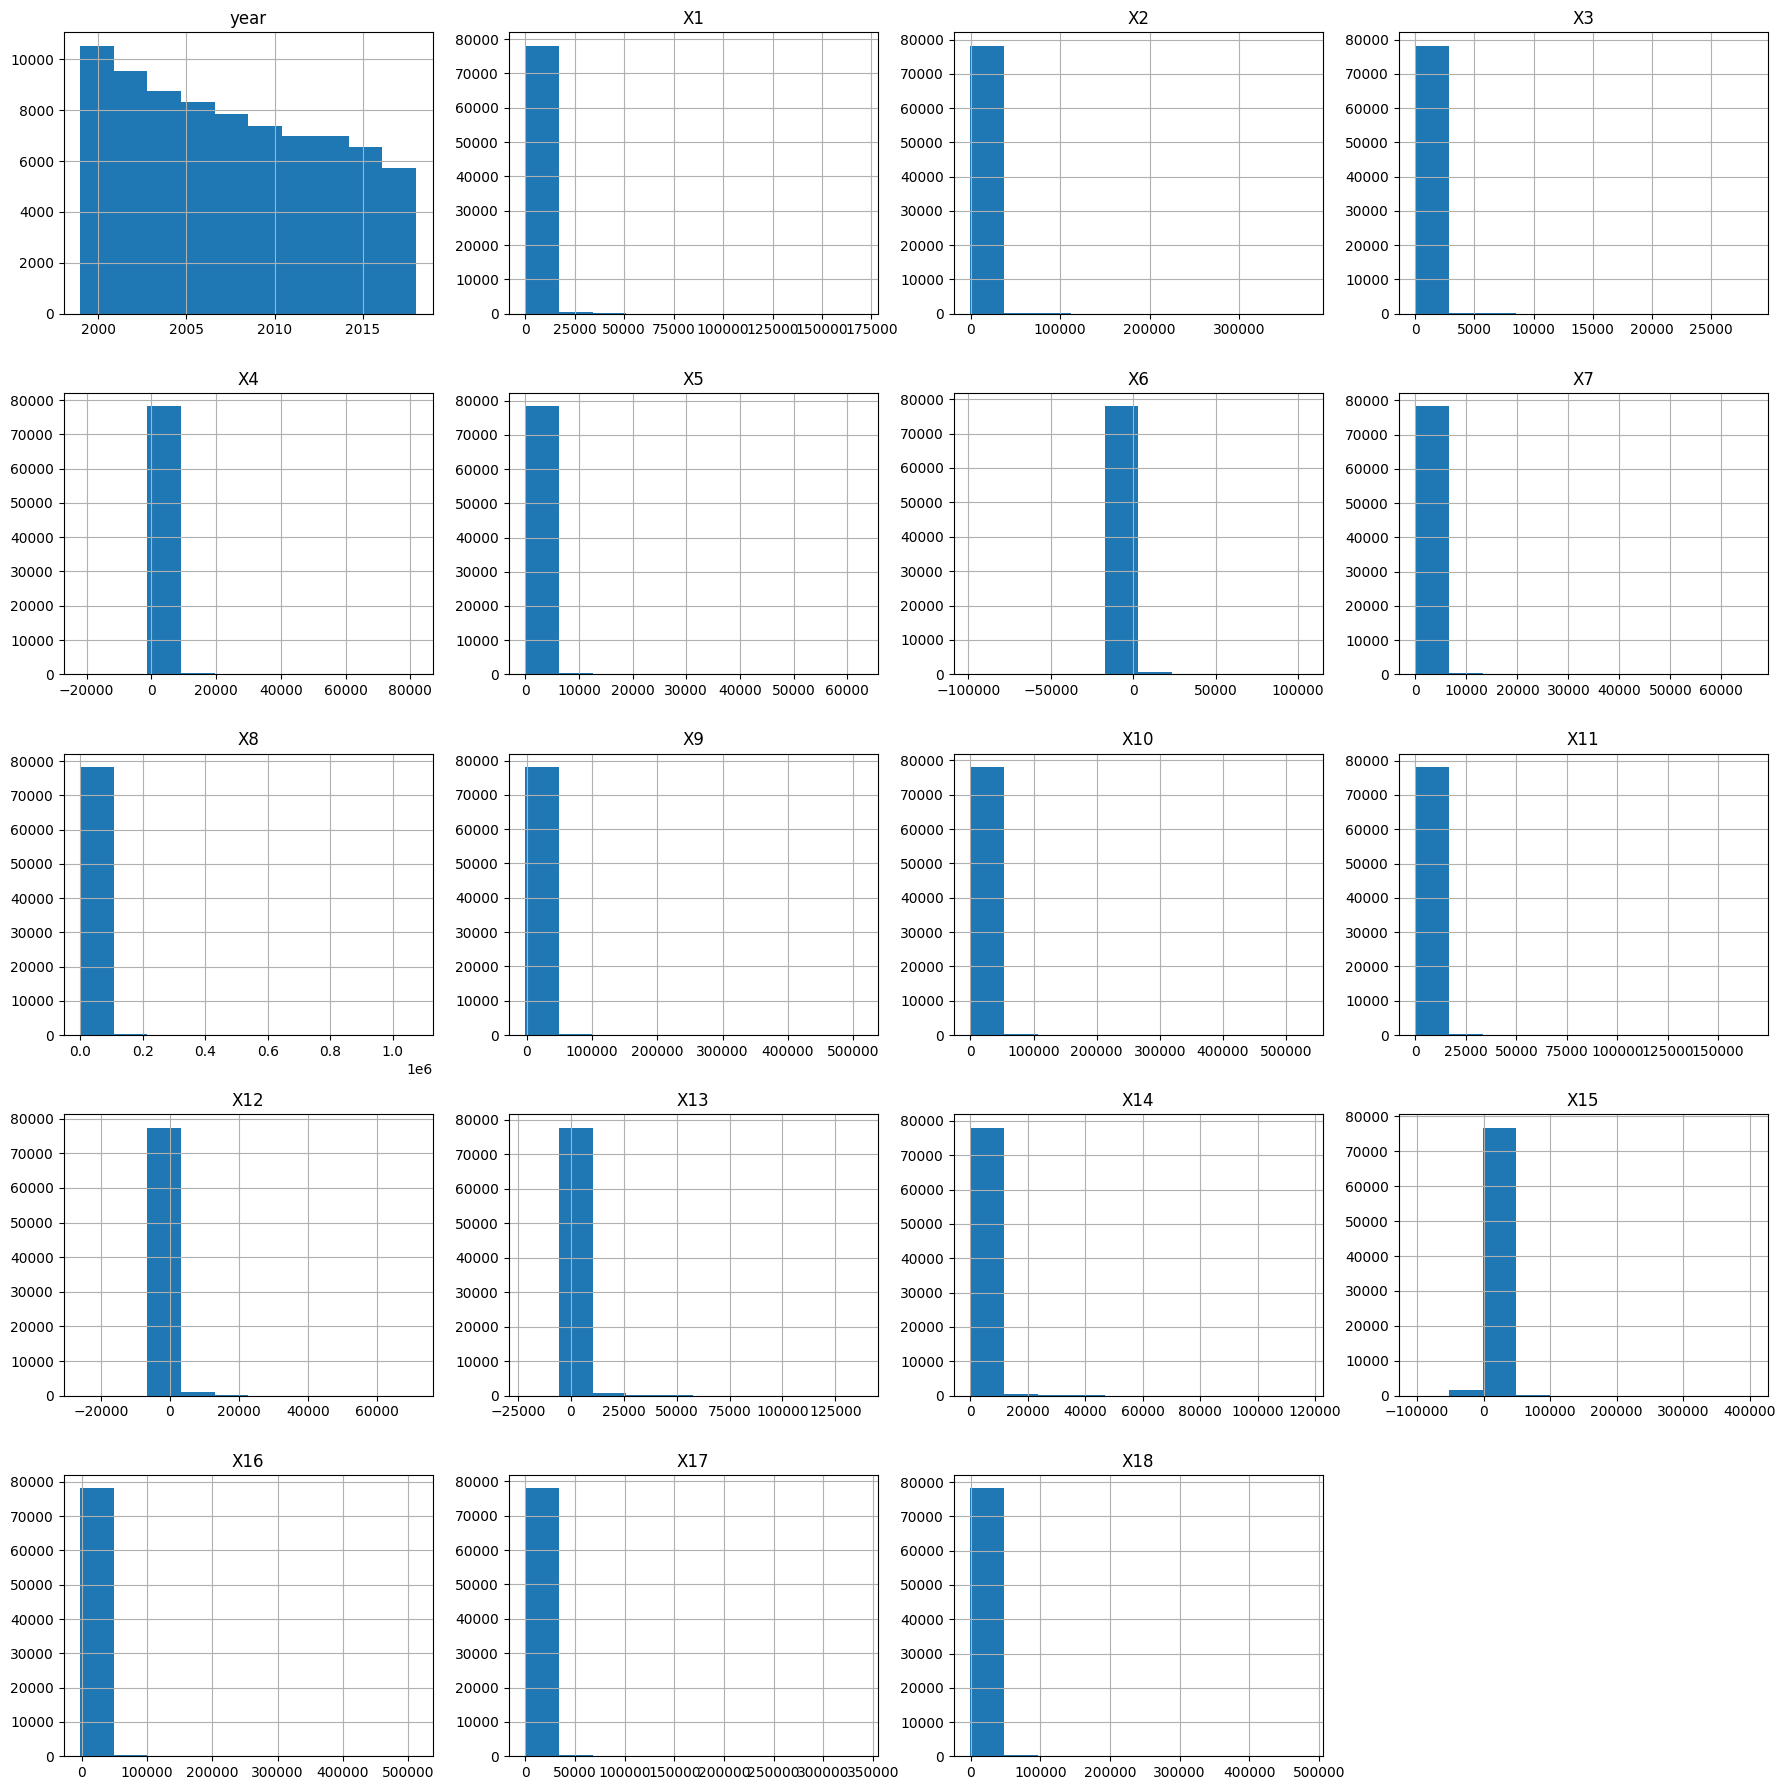

In [13]:
num.hist(figsize=(18,18));plt.tight_layout();plt.show()

## Boxplots



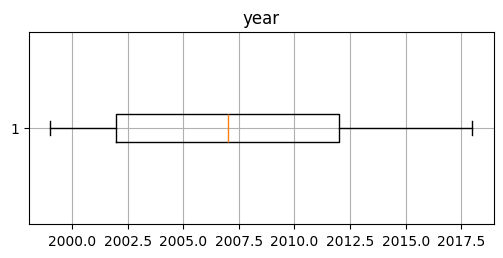

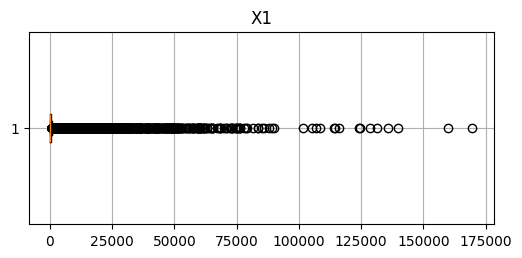

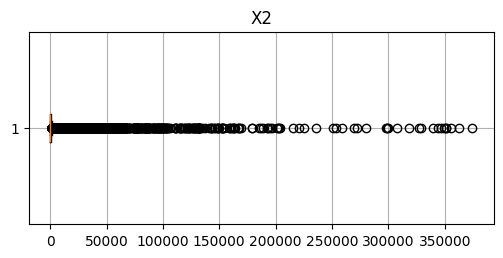

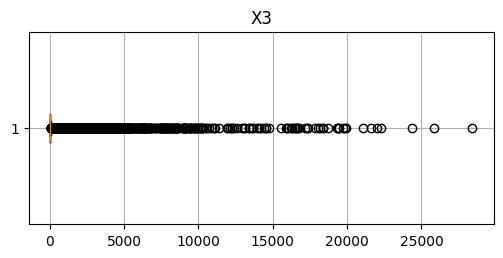

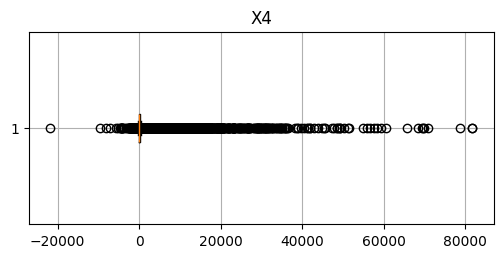

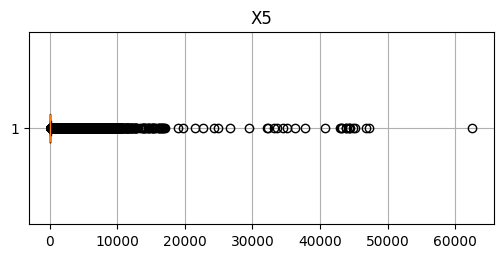

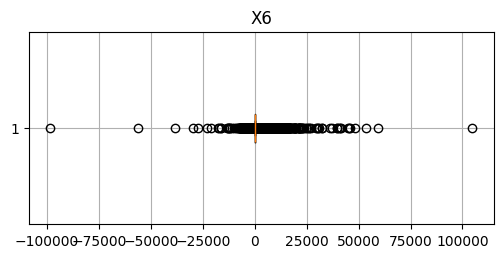

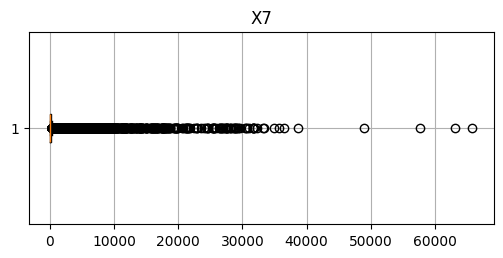

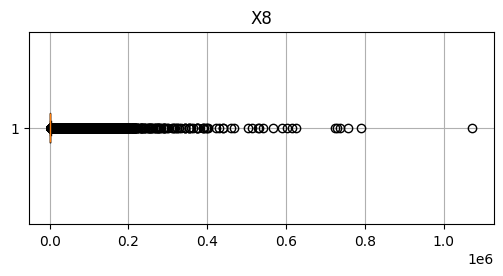

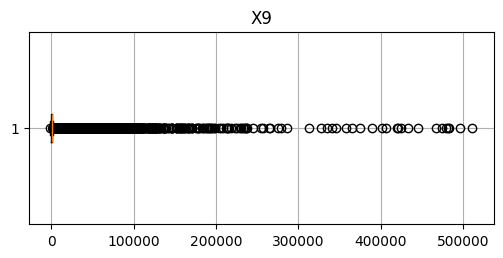

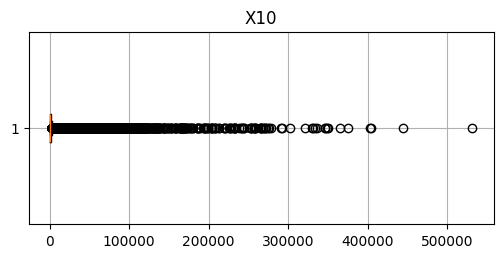

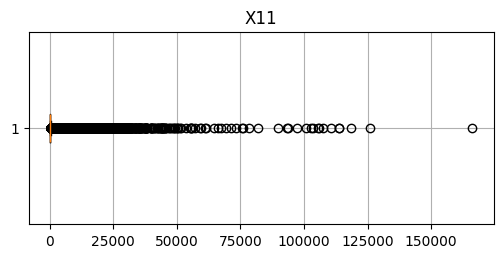

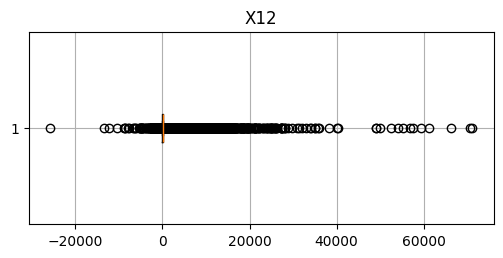

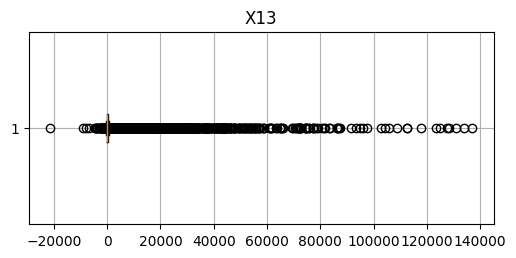

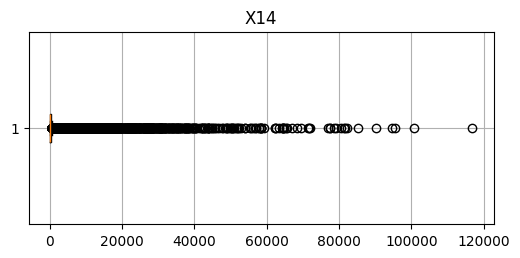

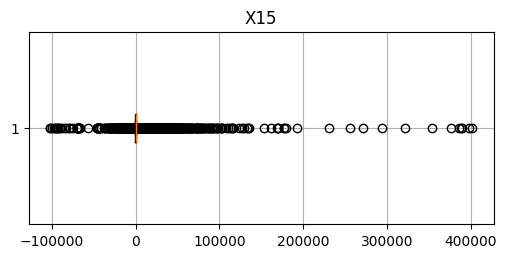

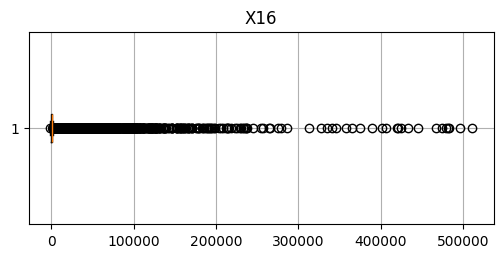

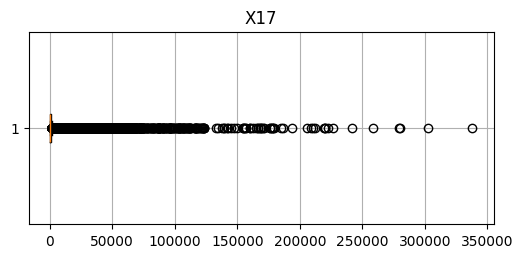

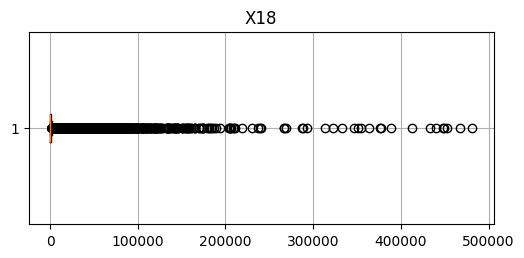

In [14]:
for c in num.columns:
    plt.figure(figsize=(6,2.5))
    plt.boxplot(df[c].dropna(),vert=False)
    plt.title(c)
    plt.show()

## Correlation



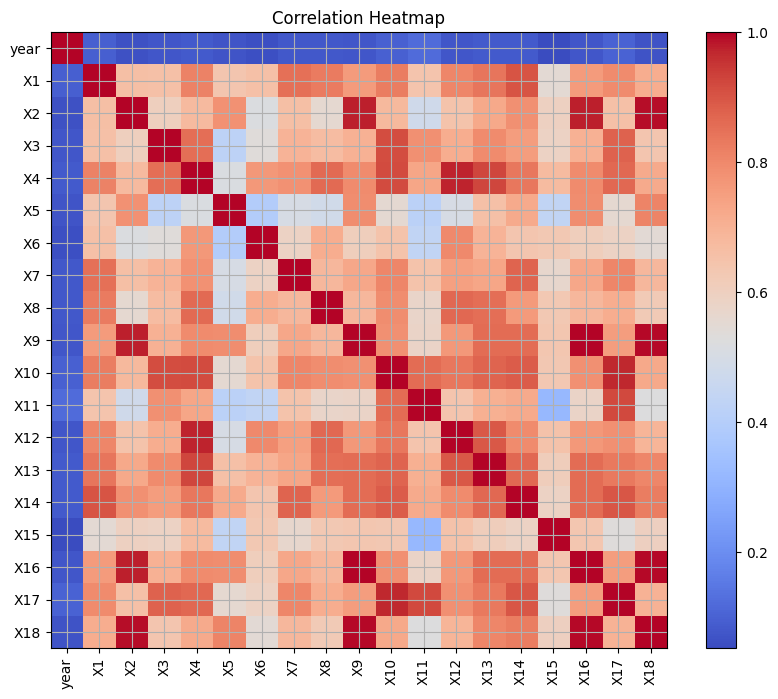

In [15]:
corr=num.corr()
fig=plt.figure(figsize=(10,8))
plt.imshow(corr,cmap='coolwarm')
plt.colorbar()
plt.xticks(range(len(corr.columns)),corr.columns,rotation=90)
plt.yticks(range(len(corr.columns)),corr.columns)
plt.title('Correlation Heatmap')
plt.show()

## Alive vs Failed



<Figure size 1000x500 with 0 Axes>

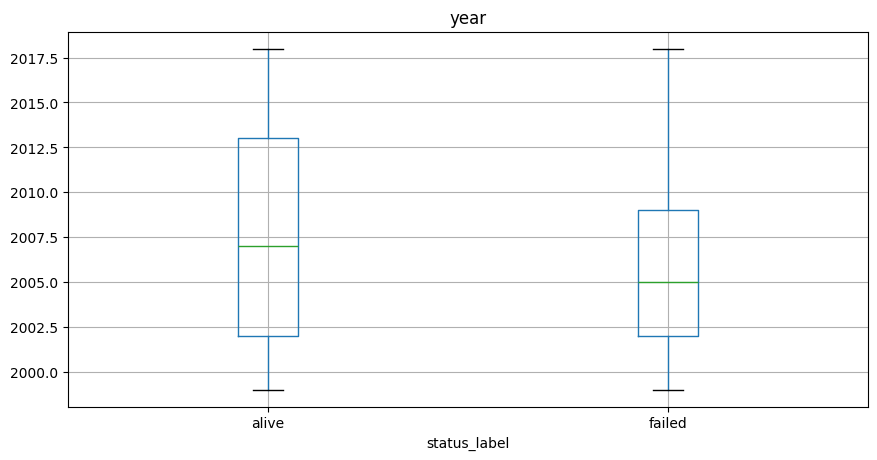

<Figure size 1000x500 with 0 Axes>

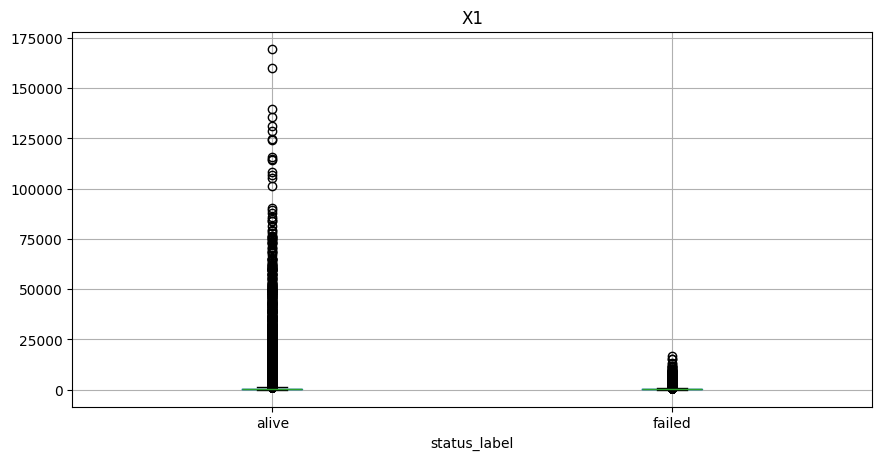

<Figure size 1000x500 with 0 Axes>

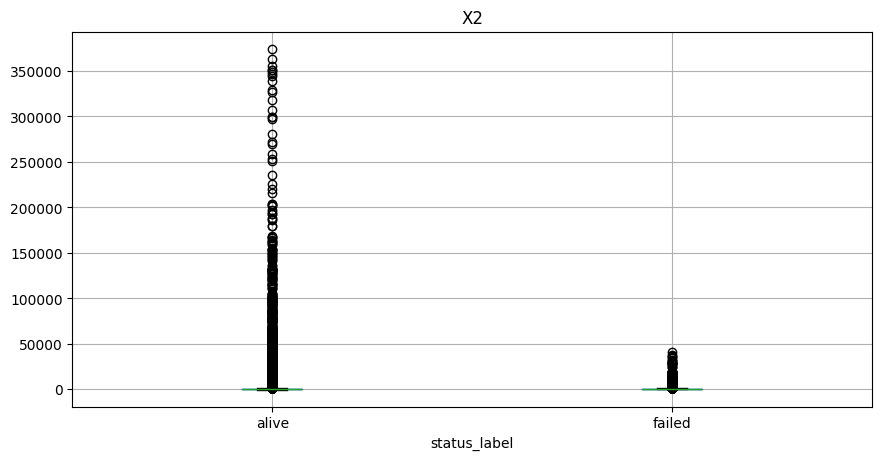

<Figure size 1000x500 with 0 Axes>

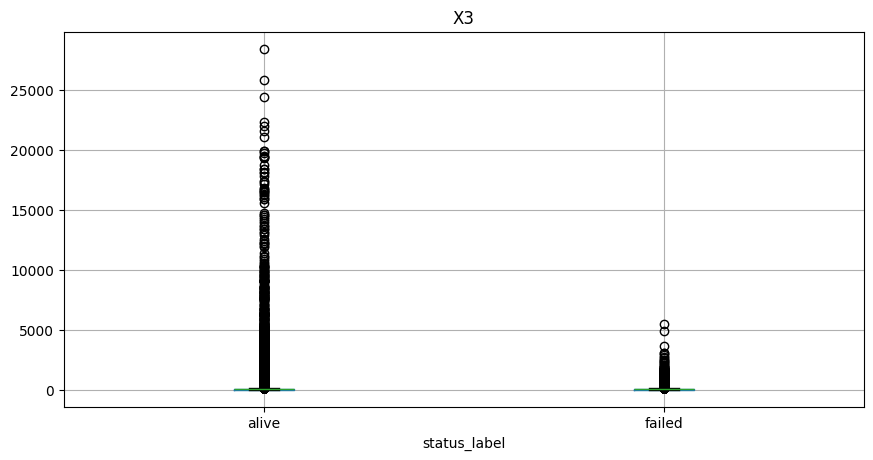

<Figure size 1000x500 with 0 Axes>

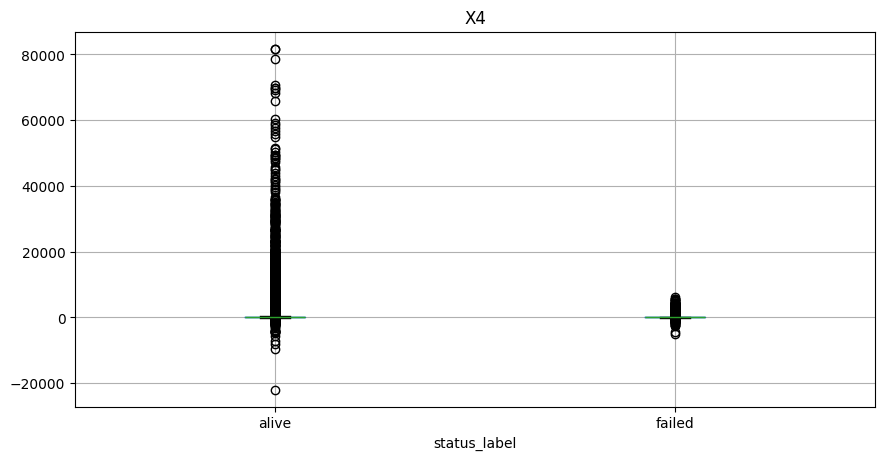

<Figure size 1000x500 with 0 Axes>

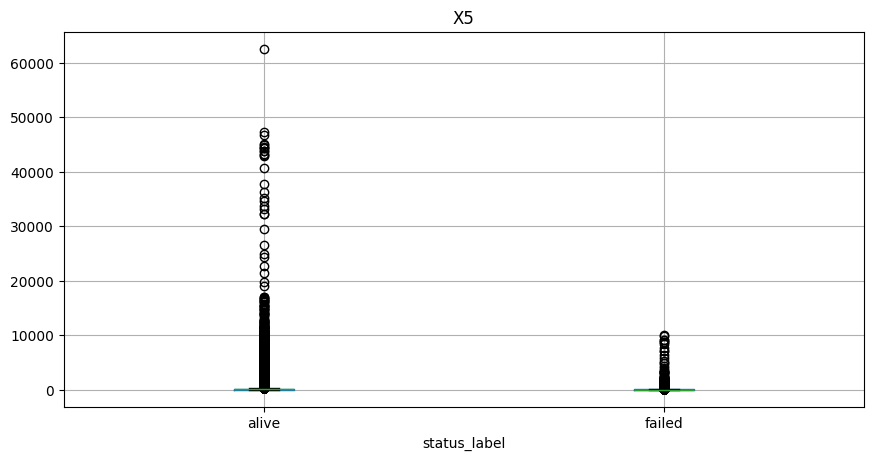

<Figure size 1000x500 with 0 Axes>

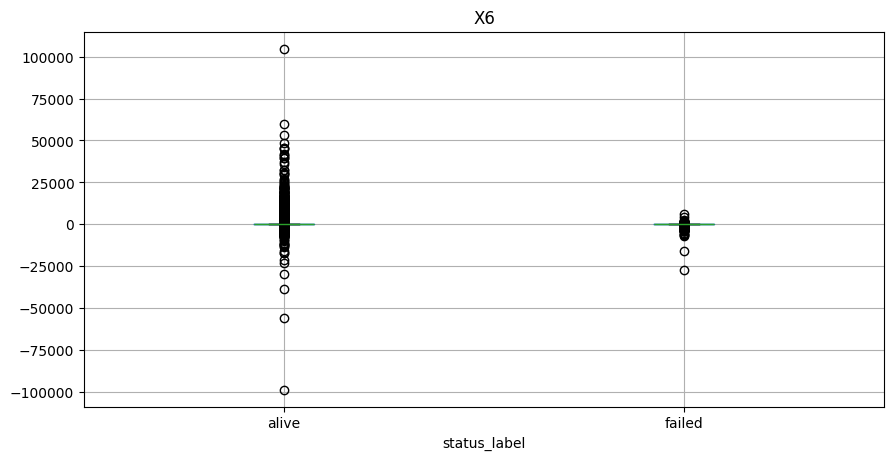

<Figure size 1000x500 with 0 Axes>

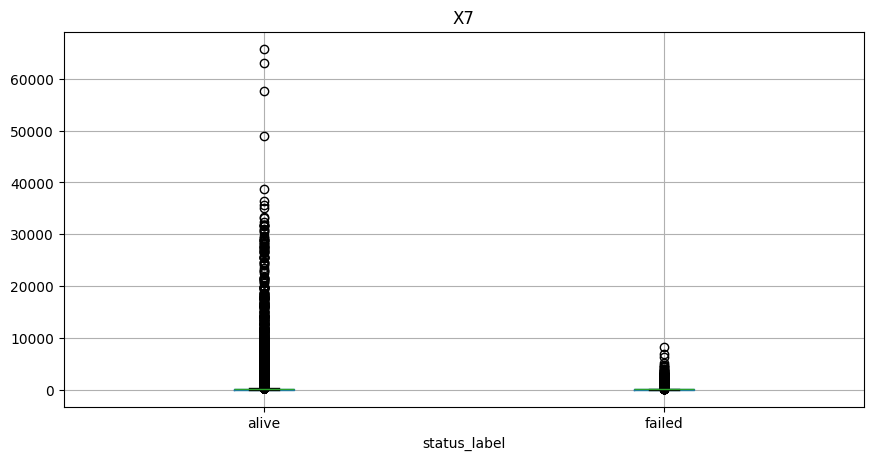

In [16]:
for c in num.columns[:8]:
    plt.figure()
    df.boxplot(column=c,by='status_label')
    plt.suptitle('')
    plt.title(c)
    plt.show()

## Outlier Report



In [17]:
Q1=num.quantile(.25);Q3=num.quantile(.75);IQR=Q3-Q1
out=((num<(Q1-1.5*IQR))|(num>(Q3+1.5*IQR))).sum().sort_values(ascending=False)
display(out.to_frame('Outlier Count'))

,Outlier Count
X15,17867
X6,17004
X12,13251
X11,12641
X5,12435
X17,12366
X4,12218
X14,11781
X2,11594
X10,11521


## Business Insights



In [18]:
print('1. Evaluate class imbalance before modeling.')
print('2. Review highly correlated variables before feature selection.')
print('3. Investigate extreme outliers before scaling.')
print('4. Document assumptions and data limitations.')

1. Evaluate class imbalance before modeling.
2. Review highly correlated variables before feature selection.
3. Investigate extreme outliers before scaling.
4. Document assumptions and data limitations.
